In [14]:
import pandas as pd


def analyze_sessions(parquet_path: str, time_column: str):
    data = pd.read_parquet(parquet_path)
    data = data[data["currency"]=='CNY']
    data["merge_date"] = pd.to_datetime(data[time_column]).dt.strftime('%Y_%m_%d')
    data["session_length"] = data.groupby(["group_id", "merge_date"])["group_id"].transform("count")

    session_stats = data["session_length"].describe()
    sessions_df = data[["group_id", "merge_date"]].drop_duplicates()

    print("session length:")
    print(session_stats)

    print("number of sessions:")
    print(len(sessions_df))
    
    return session_stats, data


In [ ]:
from pathlib import Path

PARQUET_PATH = "/Users/niuxin/Documents/aws-example/jobs/output_deepdive/deepdive_enriched_data_2025.parquet"

session_stats, processed_df = analyze_sessions(PARQUET_PATH, "billtime")


session length:
count    5.882425e+06
mean     2.844642e+01
std      4.767517e+00
min      1.000000e+00
25%      3.000000e+01
50%      3.000000e+01
75%      3.000000e+01
max      6.000000e+01
Name: session_length, dtype: float64
number of sessions:
                     group_id  merge_date
0             A0102gviplm_0_0  2025_04_10
16        A0201cc16736779_0_0  2025_04_26
35       A0201ckf15a05f40_0_0  2025_04_13
65       A0201ckf15a05f40_0_1  2025_04_13
95       A0201ckf15a05f40_0_2  2025_04_13
...                       ...         ...
5882319   V91trangdat1101_0_0  2025_01_06
5882321      V91uyen24000_0_0  2025_01_14
5882337     V97s188mantol_0_0  2025_01_11
5882367     V97s188mantol_0_1  2025_01_11
5882397     V97s188mantol_0_2  2025_01_11

[229275 rows x 2 columns]


In [ ]:
processed_df[["group_id", "merge_date", "session_length"]]

,group_id,merge_date,session_length
0,A0102gviplm_0_0,2025_04_10,16
1,A0102gviplm_0_0,2025_04_10,16
2,A0102gviplm_0_0,2025_04_10,16
3,A0102gviplm_0_0,2025_04_10,16
4,A0102gviplm_0_0,2025_04_10,16
...,...,...,...
5882420,V97s188mantol_0_2,2025_01_11,28
5882421,V97s188mantol_0_2,2025_01_11,28
5882422,V97s188mantol_0_2,2025_01_11,28
5882423,V97s188mantol_0_2,2025_01_11,28


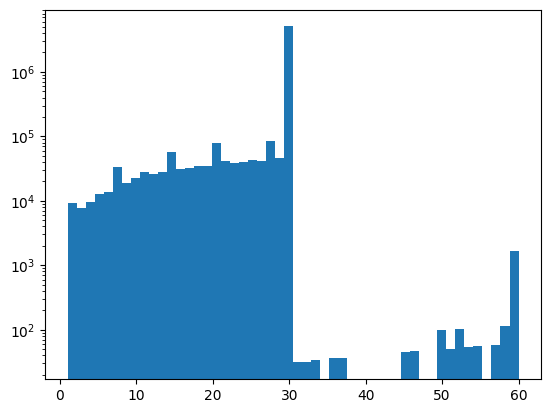

In [ ]:
import matplotlib.pyplot as plt

plt.hist(processed_df["session_length"], bins=50)
plt.yscale("log")

In [ ]:
processed_df[processed_df["session_length"] == 40]

,loginname,billno,billtime,account,cus_account,currency,slottype,basepoint,delta_t,delta_bet,delta_profit,delta_payout,result_clean,streak,win_streak,lose_streak,group_id,merge_date,session_length
